In [73]:
import pandas as pd;

In [74]:
df = pd.read_csv(r"C:\Users\hp\explainable-phishing-detector\data\raw\PhiUSIIL_Phishing_URL_Dataset.csv")

In [75]:
df.head()

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


In [76]:
df.shape

(235795, 55)

In [77]:
df.columns

Index(['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD',
       'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb',
       'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation',
       'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL',
       'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL',
       'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL',
       'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS',
       'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title',
       'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots',
       'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription',
       'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet',
       'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay',
       'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS',
       'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'labe

In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  str    
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  str    
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  int64  
 5   TLD                         235795 non-null  str    
 6   URLSimilarityIndex          235795 non-null  float64
 7   CharContinuationRate        235795 non-null  float64
 8   TLDLegitimateProb           235795 non-null  float64
 9   URLCharProb                 235795 non-null  float64
 10  TLDLength                   235795 non-null  int64  
 11  NoOfSubDomain               235795 non-null  int64  
 12  HasObfuscation              235795 non-null  int64  
 13  NoOfObfuscatedChar       

In [79]:
df.isnull().sum()

URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTitleMatchScore         0
URLTitleMatchScore            0
HasFavic

In [80]:
df["label"].value_counts()

label
1    134850
0    100945
Name: count, dtype: int64

In [81]:
df.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


In [82]:
df.duplicated().sum()

np.int64(0)

In [83]:
X = df.drop(
    columns=[
        "URL",
        "Domain",
        "TLD",
        "Title",
        "label"
    ]
)

y = df["label"]

print(X.shape)
print(y.shape)

(235795, 50)
(235795,)


In [84]:
X.head()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef
0,31,24,0,100.0,1.000000,0.522907,0.061933,3,1,0,...,1,0,0,1,34,20,28,119,0,124
1,23,16,0,100.0,0.666667,0.032650,0.050207,2,1,0,...,0,0,0,1,50,9,8,39,0,217
2,29,22,0,100.0,0.866667,0.028555,0.064129,2,2,0,...,0,0,0,1,10,2,7,42,2,5
3,26,19,0,100.0,1.000000,0.522907,0.057606,3,1,0,...,0,1,1,1,3,27,15,22,1,31
4,33,26,0,100.0,1.000000,0.079963,0.059441,3,1,0,...,1,1,0,1,244,15,34,72,1,85


In [85]:
X.shape

(235795, 50)

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% held out for testing
    random_state=42,    # makes the split reproducible
    stratify=y           # keeps the 57/43 class ratio in both splits
)

print(X_train.shape, X_test.shape)

(188636, 50) (47159, 50)


In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [88]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)

In [89]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9998727708390763

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159


Confusion Matrix:
 [[20183     6]
 [    0 26970]]


In [90]:
import pandas as pd

coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": log_reg.coef_[0]
}).sort_values(by="coefficient", key=abs, ascending=False)

print(coefficients.head(15))

                  feature  coefficient
3      URLSimilarityIndex     7.144740
21                IsHTTPS     3.910232
20  SpacialCharRatioInURL    -1.888559
13       LetterRatioInURL    -1.750995
47            NoOfSelfRef     1.637538
46                 NoOfJS     1.598587
36           HasSocialNet     1.485065
49        NoOfExternalRef     1.428235
44              NoOfImage     1.336070
15        DegitRatioInURL    -1.269880
8           NoOfSubDomain     1.235244
22             LineOfCode     1.151420
1            DomainLength     1.129755
23      LargestLineLength    -1.037715
43       HasCopyrightInfo     0.945294


In [91]:
suspects = ["URLSimilarityIndex"]

X_train_reduced = X_train.drop(columns=suspects)
X_test_reduced = X_test.drop(columns=suspects)

scaler2 = StandardScaler()
X_train_reduced_scaled = scaler2.fit_transform(X_train_reduced)
X_test_reduced_scaled = scaler2.transform(X_test_reduced)

log_reg2 = LogisticRegression(max_iter=1000)
log_reg2.fit(X_train_reduced_scaled, y_train)
y_pred2 = log_reg2.predict(X_test_reduced_scaled)

print(classification_report(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

[[20165    24]
 [   16 26954]]


In [92]:
coefficients2 = pd.DataFrame({
    "feature": X_train_reduced.columns,
    "coefficient": log_reg2.coef_[0]
}).sort_values(by="coefficient", key=abs, ascending=False)

print(coefficients2.head(15))

                       feature  coefficient
20                     IsHTTPS     7.164181
12            LetterRatioInURL    -4.825996
14             DegitRatioInURL    -4.016049
19       SpacialCharRatioInURL    -3.816811
46                 NoOfSelfRef     3.737141
45                      NoOfJS     3.706994
48             NoOfExternalRef     3.136420
43                   NoOfImage     2.990044
21                  LineOfCode     2.556940
22           LargestLineLength    -2.444772
35                HasSocialNet     2.172485
18  NoOfOtherSpecialCharsInURL    -2.139447
1                 DomainLength     2.048637
11            NoOfLettersInURL    -1.852204
23                    HasTitle     1.841264


In [93]:
df[["URL", "URLSimilarityIndex", "label"]].sample(15, random_state=1)

,URL,URLSimilarityIndex,label
71259,https://www.dkom.hr,100.000000,1
39785,https://www.loomlove.com,100.000000,1
43857,https://www.indianbureaucracy.com,100.000000,1
194428,http://ethereum-uma.com,76.378676,0
52413,https://www.alephbookcompany.com,100.000000,1
32513,https://www.handisport.org,100.000000,1
188432,https://www.cavernas.org.br,100.000000,1
115394,https://www.rewview.co.kr,100.000000,1
8887,https://www.thechronicle.com,100.000000,1
221925,https://www.blackpointt.com,81.777778,0


In [94]:
# confirm definitively — check a larger sample and see if it's consistent
df[df["label"] == 1][["URL"]].sample(10, random_state=2)
df[df["label"] == 0][["URL"]].sample(10, random_state=2)

,URL
200088,https://actubnpsteop.firebaseapp.com/
176598,http://www.gzesa.net
144955,https://bnpparibasfortis-ser1.web.app/
81280,https://meta-business-appeal-1235-2515.web.app/
64683,http://43.156.75.220/v3/signin/identifier?dsh=...
42359,http://www.tor2web.org
116895,https://btconnect-9cbbf6.webflow.io/
80726,http://www.sebastiay.cf
51146,http://www.is-a-nascarfan.com
87561,https://arweave.net/1pkjedabnpfsymefexsguvxndx...


In [95]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred2, target_names=["Phishing (0)", "Legitimate (1)"]))

                precision    recall  f1-score   support

  Phishing (0)       1.00      1.00      1.00     20189
Legitimate (1)       1.00      1.00      1.00     26970

      accuracy                           1.00     47159
     macro avg       1.00      1.00      1.00     47159
  weighted avg       1.00      1.00      1.00     47159



In [96]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_reduced, y_train)   # tree models don't need scaling
y_pred_rf = rf.predict(X_test_reduced)
print("Random Forest:\n", classification_report(y_test, y_pred_rf))

xgb = XGBClassifier(n_estimators=200, random_state=42, eval_metric="logloss")
xgb.fit(X_train_reduced, y_train)
y_pred_xgb = xgb.predict(X_test_reduced)
print("XGBoost:\n", classification_report(y_test, y_pred_xgb))

Random Forest:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

XGBoost:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



In [97]:
import sys
print(sys.executable)

c:\Users\hp\explainable-phishing-detector\venv\Scripts\python.exe


In [98]:
!pip install xgboost


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [99]:
from xgboost import XGBClassifier

In [100]:
import xgboost
print(xgboost.__version__)

3.4.1


In [101]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_reduced, y_train)   # tree models don't need scaling
y_pred_rf = rf.predict(X_test_reduced)
print("Random Forest:\n", classification_report(y_test, y_pred_rf))

xgb = XGBClassifier(n_estimators=200, random_state=42, eval_metric="logloss")
xgb.fit(X_train_reduced, y_train)
y_pred_xgb = xgb.predict(X_test_reduced)
print("XGBoost:\n", classification_report(y_test, y_pred_xgb))

Random Forest:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

XGBoost:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



In [102]:
import joblib

joblib.dump(xgb, "phishing_xgb_model.pkl")
joblib.dump(list(X_train_reduced.columns), "feature_columns.pkl")

['feature_columns.pkl']

In [103]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(xgb, X_train_reduced, y_train, cv=5, scoring="f1")
print("F1 per fold:", cv_scores)
print("Mean F1:", cv_scores.mean(), "Std:", cv_scores.std())

F1 per fold: [0.99993048 0.99993047 0.99990731 0.99993048 0.99988414]
Mean F1: 0.9999165763336553 Std: 1.853471433887551e-05


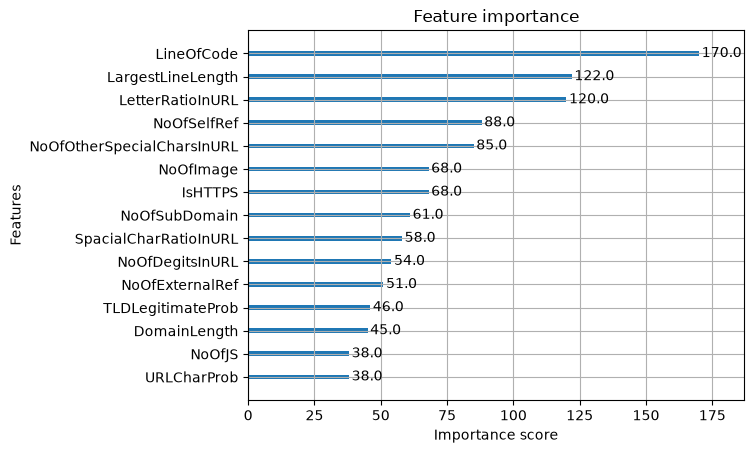

In [104]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(xgb, max_num_features=15)
plt.show()

In [105]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [106]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_reduced)

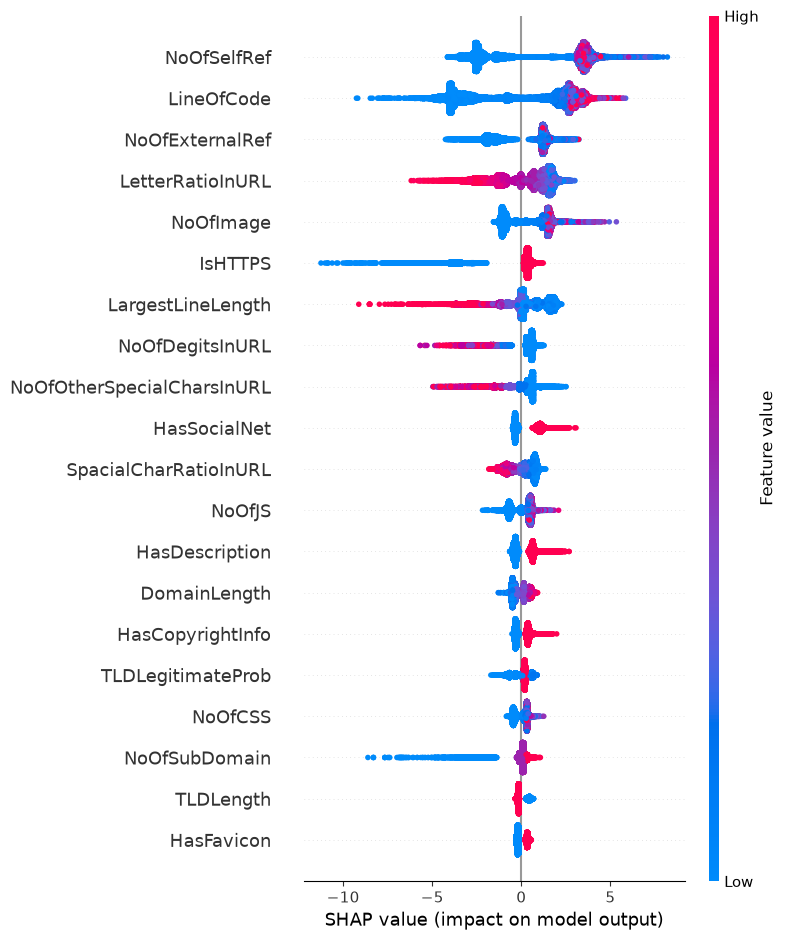

In [107]:
shap.summary_plot(shap_values, X_test_reduced)

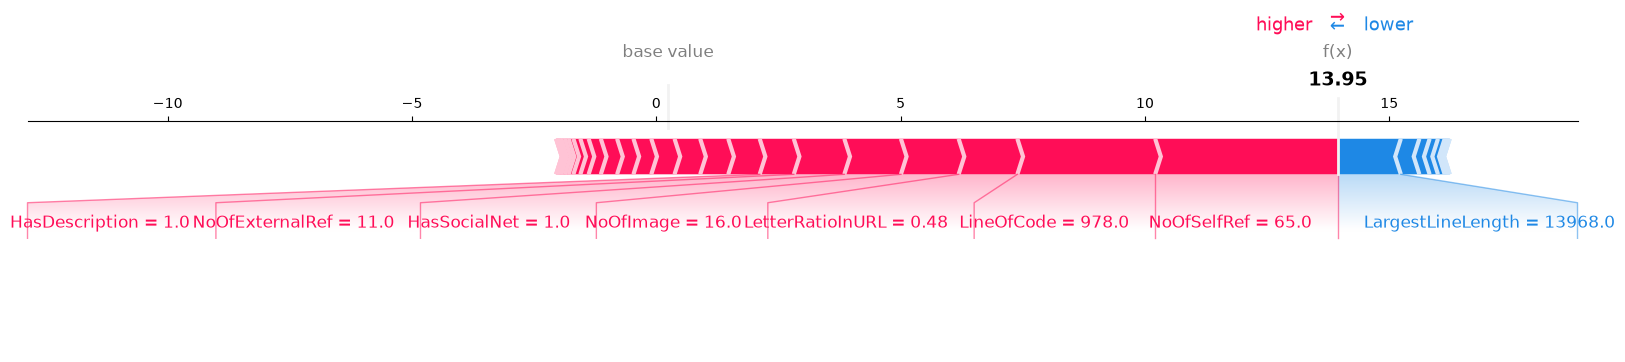

In [108]:
# pick one row from your test set to explain
idx = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test_reduced.iloc[idx],
    matplotlib=True
)

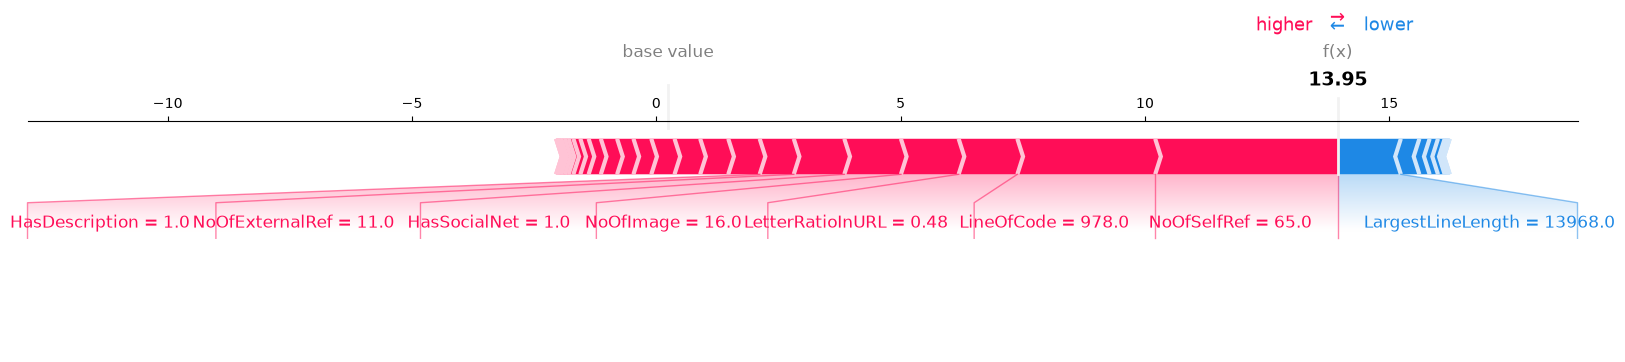

In [109]:
idx = 0  # try a few different indices to see different explanations

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test_reduced.iloc[idx],
    matplotlib=True
)

In [110]:
import pandas as pd

explanation_df = pd.DataFrame({
    "feature": X_test_reduced.columns,
    "value": X_test_reduced.iloc[idx].values,
    "shap_value": shap_values[idx]
}).sort_values(by="shap_value", key=abs, ascending=False)

print(explanation_df.head(10))
print("Predicted:", xgb.predict(X_test_reduced.iloc[[idx]])[0])
print("Actual:", y_test.iloc[idx])

                       feature     value  shap_value
46                 NoOfSelfRef     65.00    3.738626
21                  LineOfCode    978.00    2.820445
22           LargestLineLength  13968.00   -1.288572
12            LetterRatioInURL      0.48    1.201875
43                   NoOfImage     16.00    1.181248
35                HasSocialNet      1.00    1.157951
48             NoOfExternalRef     11.00    1.034802
31              HasDescription      1.00    0.697269
19       SpacialCharRatioInURL      0.04    0.643185
18  NoOfOtherSpecialCharsInURL      1.00    0.574350
Predicted: 1
Actual: 1


In [111]:
feature_descriptions = {
    # feature: (explanation when SHAP > 0 → pushes Legitimate, explanation when SHAP < 0 → pushes Phishing)
    "NoOfSelfRef":               ("Site has many internal links",         "Site has very few internal links"),
    "LineOfCode":                 ("Website has substantial page content", "Website has minimal page content"),
    "LargestLineLength":          ("Code structure looks normal",          "Unusually long code line detected"),
    "LetterRatioInURL":           ("Normal letter density in URL",         "High letter density in URL"),
    "NoOfImage":                   ("Site contains multiple images",        "Site has very few images"),
    "HasSocialNet":                ("Social media links present",           "No social media links found"),
    "NoOfExternalRef":            ("Links to external legitimate sites",   "Few or no external references"),
    "HasDescription":              ("Page has a meta description",          "Page missing a meta description"),
    "SpacialCharRatioInURL":      ("Normal special character usage",       "High special character usage in URL"),
    "NoOfOtherSpecialCharsInURL": ("URL structure looks clean",             "Unusual characters in URL"),
    "IsHTTPS":                     ("Site uses HTTPS (secure)",             "Site does NOT use HTTPS"),
}

In [112]:
def explain_prediction(idx, X_data, shap_values, model, top_n=5):
    row_shap = shap_values[idx]
    row_values = X_data.iloc[idx]

    exp_df = pd.DataFrame({
        "feature": X_data.columns,
        "value": row_values.values,
        "shap_value": row_shap
    }).sort_values(by="shap_value", key=abs, ascending=False).head(top_n)

    prediction = model.predict(X_data.iloc[[idx]])[0]
    label = "Legitimate" if prediction == 1 else "Phishing"

    reasons = []
    for _, row in exp_df.iterrows():
        feat = row["feature"]
        shap_val = row["shap_value"]

        if feat not in feature_descriptions:
            continue  # skip features you haven't mapped yet

        positive_desc, negative_desc = feature_descriptions[feat]

        # Recall: positive SHAP = pushes toward Legitimate (label 1)
        if shap_val > 0:
            reasons.append(f"+ {positive_desc}")
        else:
            reasons.append(f"- {negative_desc}")

    return {
        "prediction": label,
        "reasons": reasons
    }

In [113]:
result = explain_prediction(0, X_test_reduced, shap_values, xgb)
print("Prediction:", result["prediction"])
for r in result["reasons"]:
    print(r)

Prediction: Legitimate
+ Site has many internal links
+ Website has substantial page content
- Unusually long code line detected
+ Normal letter density in URL
+ Site contains multiple images


In [114]:
feature_descriptions.update({
    "NoOfJS":              ("Site uses substantial JavaScript",     "Site uses very little JavaScript"),
    "DomainLength":         ("Domain name length looks typical",     "Unusual domain name length"),
    "NoOfCSS":              ("Site uses structured styling (CSS)",   "Site has minimal styling"),
    "TLDLegitimateProb":    ("Domain extension is commonly trusted", "Domain extension is rarely trusted"),
    "HasFavicon":           ("Site has a favicon",                    "Site is missing a favicon"),
    "HasCopyrightInfo":     ("Copyright information present",        "No copyright information found"),
    "NoOfSubDomain":        ("Normal number of subdomains",           "Unusual number of subdomains"),
    "TLDLength":            ("Domain extension length looks normal",  "Unusual domain extension length"),
})

In [115]:
missing = [f for f in X_test_reduced.columns if f not in feature_descriptions]
print(missing)

['URLLength', 'IsDomainIP', 'CharContinuationRate', 'URLCharProb', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'NoOfEmptyRef']


In [116]:
def predict_and_explain(feature_row_df, model, explainer, top_n=5):
    """
    feature_row_df: a single-row DataFrame with the same columns as X_train_reduced
    """
    shap_vals = explainer.shap_values(feature_row_df)
    prediction = model.predict(feature_row_df)[0]
    proba = model.predict_proba(feature_row_df)[0]

    label = "Legitimate" if prediction == 1 else "Phishing"
    confidence = proba[prediction] * 100

    exp_df = pd.DataFrame({
        "feature": feature_row_df.columns,
        "value": feature_row_df.iloc[0].values,
        "shap_value": shap_vals[0]
    }).sort_values(by="shap_value", key=abs, ascending=False).head(top_n)

    reasons = []
    for _, row in exp_df.iterrows():
        feat = row["feature"]
        if feat not in feature_descriptions:
            continue
        pos_desc, neg_desc = feature_descriptions[feat]
        reasons.append(f"+ {pos_desc}" if row["shap_value"] > 0 else f"- {neg_desc}")

    return {
        "prediction": label,
        "confidence": round(confidence, 2),
        "reasons": reasons
    }

In [117]:
test_row = X_test_reduced.iloc[[1]]  # note double brackets - keeps it a DataFrame, not a Series
result = predict_and_explain(test_row, xgb, explainer)
print(result)

{'prediction': 'Legitimate', 'confidence': np.float32(100.0), 'reasons': ['+ Site has many internal links', '+ Website has substantial page content', '+ Site contains multiple images', '+ Normal letter density in URL', '+ Links to external legitimate sites']}


In [118]:
feature_descriptions.update({
    "IsDomainIP":        ("Domain name looks legitimate", "URL uses a raw IP address instead of a domain"),
    "HasObfuscation":     ("URL is clean and readable",     "URL contains obfuscated/hidden characters"),
    "NoOfEqualsInURL":    ("Normal URL structure",           "URL contains many parameters"),
    "HasPasswordField":   ("Page has expected form fields",  "Page requests password input"),
    "Bank":               ("No suspicious banking keywords", "URL contains banking-related keywords"),
    "Pay":                ("No suspicious payment keywords", "URL contains payment-related keywords"),
    "Crypto":             ("No suspicious crypto keywords",  "URL contains cryptocurrency-related keywords"),
    "NoOfURLRedirect":    ("Minimal redirection",             "Multiple URL redirects detected"),
    "HasExternalFormSubmit": ("Forms submit within the site", "Form submits data to an external site"),
})

In [119]:
import re
from urllib.parse import urlparse

def extract_url_features(url: str) -> dict:
    features = {}

    parsed = urlparse(url)
    domain = parsed.netloc.replace("www.", "")

    features["URLLength"] = len(url)
    features["DomainLength"] = len(domain)
    features["IsHTTPS"] = 1 if parsed.scheme == "https" else 0

    # is the domain a raw IP address?
    ip_pattern = r"^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$"
    features["IsDomainIP"] = 1 if re.match(ip_pattern, domain) else 0

    features["NoOfSubDomain"] = max(domain.count(".") - 1, 0)

    letters = sum(c.isalpha() for c in url)
    digits = sum(c.isdigit() for c in url)
    features["NoOfLettersInURL"] = letters
    features["LetterRatioInURL"] = letters / len(url) if len(url) else 0
    features["NoOfDegitsInURL"] = digits
    features["DegitRatioInURL"] = digits / len(url) if len(url) else 0

    special_chars = sum(not c.isalnum() for c in url)
    features["SpacialCharRatioInURL"] = special_chars / len(url) if len(url) else 0
    features["NoOfOtherSpecialCharsInURL"] = special_chars

    features["NoOfEqualsInURL"] = url.count("=")
    features["NoOfQMarkInURL"] = url.count("?")
    features["NoOfAmpersandInURL"] = url.count("&")

    tld = domain.split(".")[-1] if "." in domain else ""
    features["TLDLength"] = len(tld)

    return features

In [120]:
test_url = "https://example.com/verify-account?user=123&token=abcxyz"
print(extract_url_features(test_url))

{'URLLength': 56, 'DomainLength': 11, 'IsHTTPS': 1, 'IsDomainIP': 0, 'NoOfSubDomain': 0, 'NoOfLettersInURL': 43, 'LetterRatioInURL': 0.7678571428571429, 'NoOfDegitsInURL': 3, 'DegitRatioInURL': 0.05357142857142857, 'SpacialCharRatioInURL': 0.17857142857142858, 'NoOfOtherSpecialCharsInURL': 10, 'NoOfEqualsInURL': 2, 'NoOfQMarkInURL': 1, 'NoOfAmpersandInURL': 1, 'TLDLength': 3}


In [121]:
pip install requests beautifulsoup4

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [122]:
import requests

def fetch_page(url: str, timeout: int = 5):
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
    }
    try:
        response = requests.get(url, headers=headers, timeout=timeout, allow_redirects=True)
        return response
    except requests.exceptions.RequestException as e:
        print(f"Failed to fetch {url}: {e}")
        return None

In [123]:
resp = fetch_page("https://example.com")
print(resp.status_code)
print(resp.text[:300])  # first 300 characters of the HTML

200
<!doctype html><html lang="en"><head><title>Example Domain</title><link rel="icon" href="data:,"><meta name="viewport" content="width=device-width, initial-scale=1"><style>body{background:#eee;width:60vw;margin:15vh auto;font-family:system-ui,sans-serif}h1{font-size:1.5em}div{opacity:0.8}a:link,a:vi


In [124]:
from bs4 import BeautifulSoup

def extract_content_features(html: str) -> dict:
    soup = BeautifulSoup(html, "html.parser")
    features = {}

    features["LineOfCode"] = html.count("\n") + 1
    features["LargestLineLength"] = max((len(line) for line in html.split("\n")), default=0)

    title_tag = soup.find("title")
    features["HasTitle"] = 1 if title_tag and title_tag.text.strip() else 0

    features["NoOfImage"] = len(soup.find_all("img"))
    features["NoOfCSS"] = len(soup.find_all("link", rel="stylesheet")) + len(soup.find_all("style"))
    features["NoOfJS"] = len(soup.find_all("script"))
    features["NoOfiFrame"] = len(soup.find_all("iframe"))
    features["NoOfPopup"] = html.lower().count("window.open")

    features["HasFavicon"] = 1 if soup.find("link", rel=lambda x: x and "icon" in x.lower()) else 0
    features["HasDescription"] = 1 if soup.find("meta", attrs={"name": "description"}) else 0
    features["HasSubmitButton"] = 1 if soup.find("button", type="submit") or soup.find("input", type="submit") else 0
    features["HasPasswordField"] = 1 if soup.find("input", type="password") else 0
    features["HasHiddenFields"] = 1 if soup.find("input", type="hidden") else 0
    features["HasCopyrightInfo"] = 1 if "©" in html or "copyright" in html.lower() else 0

    social_domains = ["facebook.com", "twitter.com", "instagram.com", "linkedin.com", "x.com"]
    features["HasSocialNet"] = 1 if any(soc in html.lower() for soc in social_domains) else 0

    bank_keywords = ["bank", "account", "verify"]
    pay_keywords = ["payment", "paypal", "checkout"]
    crypto_keywords = ["crypto", "bitcoin", "wallet"]
    features["Bank"] = 1 if any(k in html.lower() for k in bank_keywords) else 0
    features["Pay"] = 1 if any(k in html.lower() for k in pay_keywords) else 0
    features["Crypto"] = 1 if any(k in html.lower() for k in crypto_keywords) else 0

    all_links = soup.find_all("a", href=True)
    self_ref = sum(1 for a in all_links if a["href"].startswith("#") or a["href"].startswith("/"))
    external_ref = sum(1 for a in all_links if a["href"].startswith("http"))
    empty_ref = sum(1 for a in all_links if a["href"] in ["#", ""])

    features["NoOfSelfRef"] = self_ref
    features["NoOfExternalRef"] = external_ref
    features["NoOfEmptyRef"] = empty_ref

    return features

In [125]:
if resp is not None:
    content_features = extract_content_features(resp.text)
    print(content_features)

{'LineOfCode': 2, 'LargestLineLength': 558, 'HasTitle': 1, 'NoOfImage': 0, 'NoOfCSS': 1, 'NoOfJS': 0, 'NoOfiFrame': 0, 'NoOfPopup': 0, 'HasFavicon': 1, 'HasDescription': 0, 'HasSubmitButton': 0, 'HasPasswordField': 0, 'HasHiddenFields': 0, 'HasCopyrightInfo': 0, 'HasSocialNet': 0, 'Bank': 0, 'Pay': 0, 'Crypto': 0, 'NoOfSelfRef': 0, 'NoOfExternalRef': 1, 'NoOfEmptyRef': 0}


In [126]:
def extract_remaining_features(url: str, html: str, response) -> dict:
    from bs4 import BeautifulSoup
    soup = BeautifulSoup(html, "html.parser")
    features = {}

    # --- Obfuscation-related ---
    # crude heuristic: % or unusual encoded chars in the URL often indicate obfuscation
    obf_chars = url.count("%")
    features["HasObfuscation"] = 1 if obf_chars > 0 else 0
    features["NoOfObfuscatedChar"] = obf_chars
    features["ObfuscationRatio"] = obf_chars / len(url) if len(url) else 0

    # --- Character continuation rate ---
    # ratio of consecutive same-type characters (rough proxy)
    continuation = sum(1 for i in range(1, len(url)) if url[i].isalpha() == url[i-1].isalpha())
    features["CharContinuationRate"] = continuation / len(url) if len(url) else 0

    # --- URLCharProb (approximate placeholder) ---
    # true version uses a trained character-probability model from the dataset authors;
    # we approximate with printable-character density as a stand-in
    printable = sum(c.isprintable() and not c.isspace() for c in url)
    features["URLCharProb"] = printable / len(url) if len(url) else 0

    # --- TLD legitimacy (approximate placeholder) ---
    common_tlds = {"com", "org", "net", "edu", "gov", "io"}
    tld = url.split("/")[2].split(".")[-1] if "//" in url else ""
    features["TLDLegitimateProb"] = 1.0 if tld in common_tlds else 0.3

    # --- Title match scores ---
    title_tag = soup.find("title")
    title_text = title_tag.text.lower() if title_tag else ""
    domain = url.split("//")[-1].split("/")[0].replace("www.", "").split(".")[0]
    features["DomainTitleMatchScore"] = 1.0 if domain.lower() in title_text else 0.0
    features["URLTitleMatchScore"] = 1.0 if domain.lower() in title_text else 0.0

    # --- Robots / responsiveness ---
    features["Robots"] = 1 if soup.find("meta", attrs={"name": "robots"}) else 0
    features["IsResponsive"] = 1 if soup.find("meta", attrs={"name": "viewport"}) else 0

    # --- Redirects ---
    features["NoOfURLRedirect"] = len(response.history) if response is not None else 0
    features["NoOfSelfRedirect"] = 0  # would need same-domain redirect check; default 0

    # --- External form submission ---
    forms = soup.find_all("form", action=True)
    features["HasExternalFormSubmit"] = 1 if any(
        f["action"].startswith("http") and domain not in f["action"] for f in forms
    ) else 0

    return features

In [127]:
import joblib
import pandas as pd

feature_columns = joblib.load("feature_columns.pkl")

def build_feature_row(url: str) -> pd.DataFrame:
    url_feats = extract_url_features(url)
    resp = fetch_page(url)

    if resp is None:
        html = ""
    else:
        html = resp.text

    content_feats = extract_content_features(html) if html else {}
    remaining_feats = extract_remaining_features(url, html, resp) if html else {}

    all_feats = {**url_feats, **content_feats, **remaining_feats}

    # ensure every expected column exists, fill missing with 0 as a safe default
    row = {col: all_feats.get(col, 0) for col in feature_columns}

    return pd.DataFrame([row])[feature_columns]

In [128]:
test_url = "https://example.com"
feature_row = build_feature_row(test_url)
print(feature_row)

result = predict_and_explain(feature_row, xgb, explainer)
print(result)

   URLLength  DomainLength  IsDomainIP  CharContinuationRate  \
0         19            11           0              0.736842   

   TLDLegitimateProb  URLCharProb  TLDLength  NoOfSubDomain  HasObfuscation  \
0                1.0          1.0          3              0               0   

   NoOfObfuscatedChar  ...  Bank  Pay  Crypto  HasCopyrightInfo  NoOfImage  \
0                   0  ...     0    0       0                 0          0   

   NoOfCSS  NoOfJS  NoOfSelfRef  NoOfEmptyRef  NoOfExternalRef  
0        1       0            0             0                1  

[1 rows x 49 columns]
{'prediction': 'Phishing', 'confidence': np.float32(100.0), 'reasons': ['- High letter density in URL', '- Website has minimal page content', '- Unusual number of subdomains', '- Site has very few internal links', '- High special character usage in URL']}


In [129]:
test_urls = [
    "https://www.wikipedia.org",
    "https://www.github.com",
    "https://www.python.org",
]

for url in test_urls:
    row = build_feature_row(url)
    result = predict_and_explain(row, xgb, explainer)
    print(url, "→", result["prediction"], result["confidence"])
    for r in result["reasons"]:
        print("   ", r)
    print()

https://www.wikipedia.org → Phishing 99.98
    - Unusual number of subdomains
    + Site has many internal links
    - High letter density in URL
    - Unusually long code line detected
    - Unusual characters in URL

https://www.github.com → Phishing 99.99
    - Unusually long code line detected
    - Unusual number of subdomains
    - High letter density in URL
    + Site has many internal links
    - Unusual characters in URL

https://www.python.org → Phishing 95.18
    - Unusual number of subdomains
    - High letter density in URL
    + Site has many internal links
    + Website has substantial page content
    - Unusual characters in URL



In [130]:
# find a legitimate (label=1) row where the domain likely still exists live
sample_row = df[df["label"] == 1].sample(5, random_state=3)
print(sample_row[["URL", "Domain"]])

                                         URL                        Domain
102312                https://www.gentner.de                www.gentner.de
28363   https://www.marine-ecosystems.org.uk  www.marine-ecosystems.org.uk
58927               https://www.somdnews.com              www.somdnews.com
13802            https://www.archreactor.org           www.archreactor.org
219779        https://www.alahlystore.com.eg        www.alahlystore.com.eg


In [131]:
chosen_url = "https://" + sample_row.iloc[0]["Domain"]  # adjust based on actual URL column format

live_row = build_feature_row(chosen_url)
stored_row = df[df["Domain"] == sample_row.iloc[0]["Domain"]][feature_columns]

comparison = pd.DataFrame({
    "live_extracted": live_row.iloc[0],
    "stored_ground_truth": stored_row.iloc[0]
})
comparison["diff"] = comparison["live_extracted"] - comparison["stored_ground_truth"]
print(comparison.sort_values(by="diff", key=abs, ascending=False))

                            live_extracted  stored_ground_truth         diff
LargestLineLength              2365.000000           950.000000  1415.000000
LineOfCode                       42.000000           639.000000  -597.000000
DomainTitleMatchScore             0.000000           100.000000  -100.000000
URLTitleMatchScore                0.000000           100.000000  -100.000000
NoOfImage                         2.000000            63.000000   -61.000000
NoOfSelfRef                       0.000000            50.000000   -50.000000
NoOfExternalRef                   2.000000            11.000000    -9.000000
NoOfLettersInURL                 17.000000             8.000000     9.000000
DomainLength                     10.000000            14.000000    -4.000000
NoOfOtherSpecialCharsInURL        5.000000             1.000000     4.000000
URLLength                        22.000000            21.000000     1.000000
NoOfSubDomain                     0.000000             1.000000    -1.000000

In [132]:
def extract_url_features(url: str) -> dict:
    features = {}

    parsed = urlparse(url)
    domain = parsed.netloc.replace("www.", "")

    features["URLLength"] = len(url)
    features["DomainLength"] = len(domain)
    features["IsHTTPS"] = 1 if parsed.scheme == "https" else 0

    ip_pattern = r"^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$"
    features["IsDomainIP"] = 1 if re.match(ip_pattern, domain) else 0

    # FIX: use parsed.netloc (includes www) instead of the www-stripped `domain`
    features["NoOfSubDomain"] = max(parsed.netloc.count(".") - 1, 0)

    letters = sum(c.isalpha() for c in url)
    digits = sum(c.isdigit() for c in url)
    features["NoOfLettersInURL"] = letters
    features["LetterRatioInURL"] = letters / len(url) if len(url) else 0
    features["NoOfDegitsInURL"] = digits
    features["DegitRatioInURL"] = digits / len(url) if len(url) else 0

    special_chars = sum(not c.isalnum() for c in url)
    features["SpacialCharRatioInURL"] = special_chars / len(url) if len(url) else 0
    features["NoOfOtherSpecialCharsInURL"] = special_chars

    features["NoOfEqualsInURL"] = url.count("=")
    features["NoOfQMarkInURL"] = url.count("?")
    features["NoOfAmpersandInURL"] = url.count("&")

    tld = domain.split(".")[-1] if "." in domain else ""
    features["TLDLength"] = len(tld)

    return features

In [133]:
for url in test_urls:
    row = build_feature_row(url)
    result = predict_and_explain(row, xgb, explainer)
    print(url, "→", result["prediction"], result["confidence"])

https://www.wikipedia.org → Phishing 99.74
https://www.github.com → Phishing 99.98
https://www.python.org → Phishing 59.95


In [134]:
sample_row = df[df["label"] == 1].sample(5, random_state=3)
print(sample_row[["URL", "Domain"]])

                                         URL                        Domain
102312                https://www.gentner.de                www.gentner.de
28363   https://www.marine-ecosystems.org.uk  www.marine-ecosystems.org.uk
58927               https://www.somdnews.com              www.somdnews.com
13802            https://www.archreactor.org           www.archreactor.org
219779        https://www.alahlystore.com.eg        www.alahlystore.com.eg


In [135]:
chosen_domain = sample_row.iloc[0]["Domain"]   # e.g. "wikipedia.org"
chosen_url = "https://" + chosen_domain

live_row = build_feature_row(chosen_url)
stored_row = df[df["Domain"] == chosen_domain][feature_columns]

comparison = pd.DataFrame({
    "live_extracted": live_row.iloc[0].values,
    "stored_ground_truth": stored_row.iloc[0].values
}, index=feature_columns)

comparison["diff"] = comparison["live_extracted"] - comparison["stored_ground_truth"]
comparison["abs_diff"] = comparison["diff"].abs()
print(comparison.sort_values(by="abs_diff", ascending=False).head(20))

                            live_extracted  stored_ground_truth    diff  \
LargestLineLength                   2365.0                950.0  1415.0   
LineOfCode                            42.0                639.0  -597.0   
DomainTitleMatchScore                  0.0                100.0  -100.0   
URLTitleMatchScore                     0.0                100.0  -100.0   
NoOfImage                              2.0                 63.0   -61.0   
NoOfSelfRef                            0.0                 50.0   -50.0   
NoOfExternalRef                        2.0                 11.0    -9.0   
NoOfLettersInURL                      17.0                  8.0     9.0   
DomainLength                          10.0                 14.0    -4.0   
NoOfOtherSpecialCharsInURL             5.0                  1.0     4.0   
URLLength                             22.0                 21.0     1.0   
HasFavicon                             0.0                  1.0    -1.0   
NoOfiFrame               

In [136]:
resp = fetch_page("https://www.gentner.de")
print(len(resp.text))
print(resp.text[:2000])

4353
<!doctype html><html lang="en"><head><title>Making sure you&#39;re not a bot!</title><link rel="stylesheet" href="/.within.website/x/xess/xess.min.css?cachebuster=v1.25.0"><meta name="viewport" content="width=device-width, initial-scale=1.0"><meta name="robots" content="noindex,nofollow"><style>
        body,
        html {
            height: 100%;
            display: flex;
            justify-content: center;
            align-items: center;
            margin-left: auto;
            margin-right: auto;
        }

        .centered-div {
            text-align: center;
        }

        #status {
            font-variant-numeric: tabular-nums;
        }

        #progress {
            display: none;
            width: 90%;
            width: min(20rem, 90%);
            height: 2rem;
            border-radius: 1rem;
            overflow: hidden;
            margin: 1rem 0 2rem;
            outline-offset: 2px;
            outline: #b16286 solid 4px;
        }

        .bar-in

In [137]:
def extract_remaining_features(url: str, html: str, response) -> dict:
    from bs4 import BeautifulSoup
    soup = BeautifulSoup(html, "html.parser")
    features = {}

    obf_chars = url.count("%")
    features["HasObfuscation"] = 1 if obf_chars > 0 else 0
    features["NoOfObfuscatedChar"] = obf_chars
    features["ObfuscationRatio"] = obf_chars / len(url) if len(url) else 0

    continuation = sum(1 for i in range(1, len(url)) if url[i].isalpha() == url[i-1].isalpha())
    features["CharContinuationRate"] = continuation / len(url) if len(url) else 0

    printable = sum(c.isprintable() and not c.isspace() for c in url)
    features["URLCharProb"] = printable / len(url) if len(url) else 0

    common_tlds = {"com", "org", "net", "edu", "gov", "io"}
    tld = url.split("/")[2].split(".")[-1] if "//" in url else ""
    features["TLDLegitimateProb"] = 1.0 if tld in common_tlds else 0.3

    title_tag = soup.find("title")
    title_text = title_tag.text.lower() if title_tag else ""
    domain = url.split("//")[-1].split("/")[0].replace("www.", "").split(".")[0]

    # FIX: scale to 0-100, matching the original dataset
    features["DomainTitleMatchScore"] = 100.0 if domain.lower() in title_text else 0.0
    features["URLTitleMatchScore"] = 100.0 if domain.lower() in title_text else 0.0

    features["Robots"] = 1 if soup.find("meta", attrs={"name": "robots"}) else 0
    features["IsResponsive"] = 1 if soup.find("meta", attrs={"name": "viewport"}) else 0

    features["NoOfURLRedirect"] = len(response.history) if response is not None else 0
    features["NoOfSelfRedirect"] = 0

    forms = soup.find_all("form", action=True)
    features["HasExternalFormSubmit"] = 1 if any(
        f["action"].startswith("http") and domain not in f["action"] for f in forms
    ) else 0

    return features

In [138]:
!pip install playwright
!playwright install chromium


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [139]:
from playwright.async_api import async_playwright

async def fetch_rendered_page(url: str, timeout: int = 10000) -> str:
    async with async_playwright() as p:
        browser = await p.chromium.launch()
        page = await browser.new_page()
        try:
            await page.goto(url, timeout=timeout, wait_until="networkidle")
            html = await page.content()
        except Exception as e:
            print(f"Failed to render {url}: {e}")
            html = ""
        finally:
            await browser.close()
    return html

In [140]:
def fetch_rendered_page(url: str, timeout: int = 20000) -> str:
    result = {"html": ""}

    def runner():
        asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)

        async def _fetch():
            async with async_playwright() as p:
                browser = await p.chromium.launch()
                page = await browser.new_page()
                try:
                    await page.goto(url, timeout=timeout, wait_until="domcontentloaded")
                    await page.wait_for_timeout(2000)  # small grace period for late JS rendering
                    result["html"] = await page.content()
                except Exception as e:
                    print(f"Failed to render {url}: {e}")
                finally:
                    await browser.close()

        loop.run_until_complete(_fetch())
        loop.close()

    thread = threading.Thread(target=runner)
    thread.start()
    thread.join()
    return result["html"]

In [142]:
test_html = fetch_rendered_page("https://www.python.org")
print(len(test_html))
print(test_html[:500])

NameError: name 'threading' is not defined

In [143]:
def build_feature_row(url: str) -> pd.DataFrame:
    url_feats = extract_url_features(url)
    html = fetch_rendered_page(url)

    content_feats = extract_content_features(html) if html else {}
    remaining_feats = extract_remaining_features(url, html, None) if html else {}

    all_feats = {**url_feats, **content_feats, **remaining_feats}
    row = {col: all_feats.get(col, 0) for col in feature_columns}

    return pd.DataFrame([row])[feature_columns]

In [144]:
chosen_domain = "www.gentner.de"
chosen_url = "https://" + chosen_domain

live_row = build_feature_row(chosen_url)
stored_row = df[df["Domain"] == chosen_domain][feature_columns]

comparison = pd.DataFrame({
    "live_extracted": live_row.iloc[0].values,
    "stored_ground_truth": stored_row.iloc[0].values
}, index=feature_columns)

comparison["diff"] = comparison["live_extracted"] - comparison["stored_ground_truth"]
comparison["abs_diff"] = comparison["diff"].abs()
print(comparison.sort_values(by="abs_diff", ascending=False).head(20))

NameError: name 'threading' is not defined

In [145]:
test_urls = [
    "https://www.wikipedia.org",
    "https://www.github.com",
    "https://www.python.org",
]

for url in test_urls:
    row = build_feature_row(url)
    result = predict_and_explain(row, xgb, explainer)
    print(url, "→", result["prediction"], result["confidence"])
    for r in result["reasons"]:
        print("   ", r)
    print()

NameError: name 'threading' is not defined

In [182]:
url_only_features = [
    "URLLength", "DomainLength", "IsDomainIP", "NoOfSubDomain",
    "NoOfLettersInURL", "LetterRatioInURL", "NoOfDegitsInURL", "DegitRatioInURL",
    "NoOfEqualsInURL", "NoOfQMarkInURL", "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL", "SpacialCharRatioInURL",
    "TLDLength", "IsHTTPS", "HasObfuscation", "NoOfObfuscatedChar", "ObfuscationRatio"
]

X_url_only = df[url_only_features]
y = df["label"]

X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_url_only, y, test_size=0.2, random_state=42, stratify=y
)

from xgboost import XGBClassifier
xgb_url_only = XGBClassifier(n_estimators=200, random_state=42, eval_metric="logloss")
xgb_url_only.fit(X_train_u, y_train_u)

y_pred_u = xgb_url_only.predict(X_test_u)
print(classification_report(y_test_u, y_pred_u))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



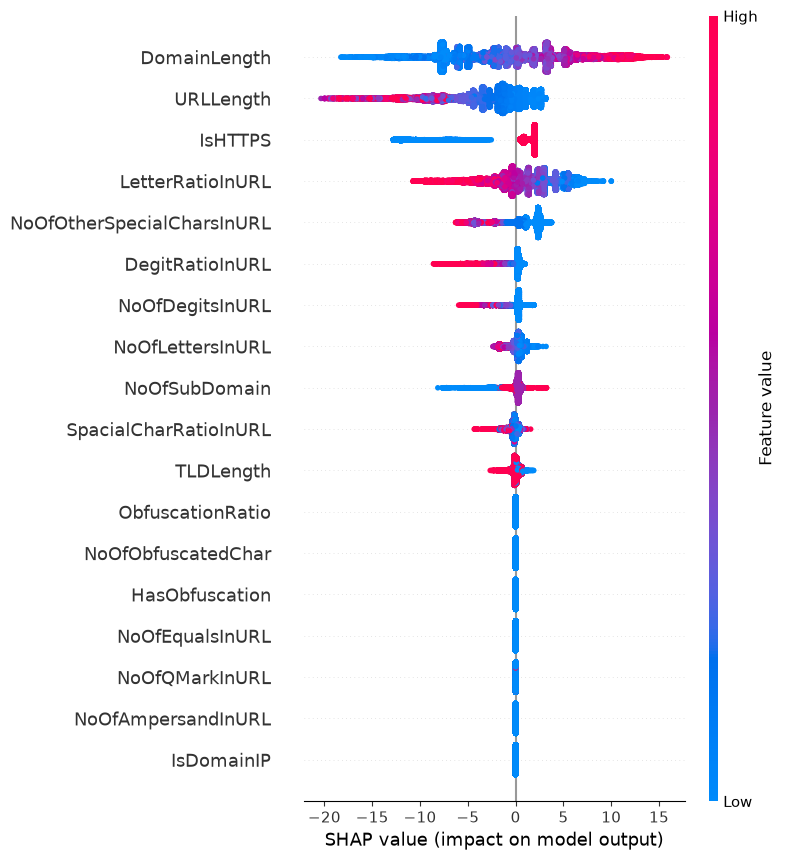

In [147]:
explainer_url_only = shap.TreeExplainer(xgb_url_only)
shap_values_url_only = explainer_url_only.shap_values(X_test_u)

shap.summary_plot(shap_values_url_only, X_test_u)

In [148]:
joblib.dump(xgb_url_only, "phishing_xgb_url_only_model.pkl")
joblib.dump(url_only_features, "url_only_feature_columns.pkl")

['url_only_feature_columns.pkl']

In [149]:
def build_url_only_feature_row(url: str) -> pd.DataFrame:
    feats = extract_url_features(url)
    row = {col: feats.get(col, 0) for col in url_only_features}
    return pd.DataFrame([row])[url_only_features]

def predict_and_explain_url_only(url: str, top_n=5):
    row = build_url_only_feature_row(url)
    shap_vals = explainer_url_only.shap_values(row)
    prediction = xgb_url_only.predict(row)[0]
    proba = xgb_url_only.predict_proba(row)[0]

    label = "Legitimate" if prediction == 1 else "Phishing"
    confidence = round(proba[prediction] * 100, 2)

    exp_df = pd.DataFrame({
        "feature": row.columns,
        "value": row.iloc[0].values,
        "shap_value": shap_vals[0]
    }).sort_values(by="shap_value", key=abs, ascending=False).head(top_n)

    reasons = []
    for _, r in exp_df.iterrows():
        feat = r["feature"]
        if feat not in feature_descriptions:
            continue
        pos_desc, neg_desc = feature_descriptions[feat]
        reasons.append(f"+ {pos_desc}" if r["shap_value"] > 0 else f"- {neg_desc}")

    return {"prediction": label, "confidence": confidence, "reasons": reasons}

In [150]:
test_urls = [
    "https://www.wikipedia.org",
    "https://www.github.com",
    "https://www.python.org",
    "https://paypa1-secure-login-verify.com",  # a plausible-looking fake phishing example
]

for url in test_urls:
    result = predict_and_explain_url_only(url)
    print(url, "→", result["prediction"], result["confidence"])
    for r in result["reasons"]:
        print("   ", r)
    print()

https://www.wikipedia.org → Phishing 100.0
    - Unusual domain name length
    - High letter density in URL
    - Unusual characters in URL
    - High special character usage in URL

https://www.github.com → Phishing 100.0
    - Unusual domain name length
    - High letter density in URL
    - Unusual characters in URL
    - High special character usage in URL

https://www.python.org → Phishing 100.0
    - Unusual domain name length
    - High letter density in URL
    - Unusual characters in URL
    - High special character usage in URL

https://paypa1-secure-login-verify.com → Phishing 100.0
    - High letter density in URL
    + Domain name length looks typical
    - Unusual characters in URL
    - Unusual number of subdomains



In [151]:
pd.set_option('display.max_colwidth', None)

print("LEGITIMATE (label=1) examples:")
print(df[df["label"] == 1]["URL"].sample(10, random_state=5).to_string())

print("\nPHISHING (label=0) examples:")
print(df[df["label"] == 0]["URL"].sample(10, random_state=5).to_string())

LEGITIMATE (label=1) examples:
188219                  https://www.pope.af.mil
95853                  https://www.mtishows.com
103042    https://www.capeyorkwaterquality.info
50285              https://www.kaine.senate.gov
52723         https://www.applied-acoustics.com
66396                     https://www.usjjf.org
170345     https://www.braintalkcommunities.org
26800             https://www.phuongtruongan.vn
50886               https://www.lemonchecks.com
234080           https://www.naturopathy-uk.com

PHISHING (label=0) examples:
59153                                      http://www.smespacnbit-infofr.web.app
51581                                                  http://www.cert-center.ir
177190                                            http://tinyurl.com/bpercardnet
43200                              https://sucursalvirualsadsa.asdwdwed.repl.co/
133489                                         https://redirectionsplus.web.app/
63777                                             http

In [152]:
print(df.groupby("label")["URLLength"].describe())
print(df.groupby("label")["DomainLength"].describe())

          count       mean        std   min   25%   50%   75%     max
label                                                                
0      100945.0  45.720293  61.145523  13.0  26.0  34.0  48.0  6097.0
1      134850.0  26.228610   4.815612  15.0  23.0  26.0  29.0    57.0
          count       mean        std  min   25%   50%   75%    max
label                                                              
0      100945.0  24.465144  12.204054  4.0  16.0  22.0  29.0  110.0
1      134850.0  19.228610   4.815612  8.0  16.0  19.0  22.0   50.0


In [153]:
def extract_url_features(url: str) -> dict:
    features = {}

    parsed = urlparse(url)
    domain = parsed.netloc  # FIX: keep www. — don't strip it, match dataset's methodology

    features["URLLength"] = len(url)
    features["DomainLength"] = len(domain)
    features["IsHTTPS"] = 1 if parsed.scheme == "https" else 0

    ip_pattern = r"^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$"
    features["IsDomainIP"] = 1 if re.match(ip_pattern, domain) else 0

    features["NoOfSubDomain"] = max(parsed.netloc.count(".") - 1, 0)

    letters = sum(c.isalpha() for c in url)
    digits = sum(c.isdigit() for c in url)
    features["NoOfLettersInURL"] = letters
    features["LetterRatioInURL"] = letters / len(url) if len(url) else 0
    features["NoOfDegitsInURL"] = digits
    features["DegitRatioInURL"] = digits / len(url) if len(url) else 0

    special_chars = sum(not c.isalnum() for c in url)
    features["SpacialCharRatioInURL"] = special_chars / len(url) if len(url) else 0
    features["NoOfOtherSpecialCharsInURL"] = special_chars

    features["NoOfEqualsInURL"] = url.count("=")
    features["NoOfQMarkInURL"] = url.count("?")
    features["NoOfAmpersandInURL"] = url.count("&")

    tld = domain.split(".")[-1] if "." in domain else ""
    features["TLDLength"] = len(tld)

    return features

In [154]:
sample = df[df["label"] == 1].iloc[0]
print(sample["URL"], "→ stored DomainLength:", sample["DomainLength"])

parsed = urlparse(sample["URL"])
print("With www kept:", len(parsed.netloc))
print("With www stripped:", len(parsed.netloc.replace("www.", "")))

https://www.southbankmosaics.com → stored DomainLength: 24
With www kept: 24
With www stripped: 20


In [155]:
test_urls = [
    "https://www.wikipedia.org",
    "https://www.github.com",
    "https://www.python.org",
    "https://paypa1-secure-login-verify.com",
]

for url in test_urls:
    result = predict_and_explain_url_only(url)
    print(url, "→", result["prediction"], result["confidence"])
    for r in result["reasons"]:
        print("   ", r)
    print()

https://www.wikipedia.org → Phishing 100.0
    - High letter density in URL
    - Unusual domain name length
    - Unusual characters in URL
    - High special character usage in URL

https://www.github.com → Phishing 100.0
    - Unusual domain name length
    - High letter density in URL
    - Unusual characters in URL
    - High special character usage in URL
    + Site uses HTTPS (secure)

https://www.python.org → Phishing 100.0
    - Unusual domain name length
    - High letter density in URL
    - Unusual characters in URL
    - High special character usage in URL
    + Site uses HTTPS (secure)

https://paypa1-secure-login-verify.com → Phishing 100.0
    - High letter density in URL
    + Domain name length looks typical
    - Unusual characters in URL
    - Unusual number of subdomains



In [160]:
wiki_features = extract_url_features("https://www.wikipedia.org")
for k, v in wiki_features.items():
    print(f"{k}: {v}")

URLLength: 25
DomainLength: 17
IsHTTPS: 1
IsDomainIP: 0
NoOfSubDomain: 1
NoOfLettersInURL: 20
LetterRatioInURL: 0.8
NoOfDegitsInURL: 0
DegitRatioInURL: 0.0
SpacialCharRatioInURL: 0.2
NoOfOtherSpecialCharsInURL: 5
NoOfEqualsInURL: 0
NoOfQMarkInURL: 0
NoOfAmpersandInURL: 0
TLDLength: 3


In [161]:
# find a legitimate row with a bare domain (no path), similar length to wikipedia's URL
similar = df[
    (df["label"] == 1) &
    (df["URLLength"].between(20, 30)) &
    (~df["URL"].str.contains(r"\.\w+/", regex=True))  # no path after domain
].sample(1, random_state=7)

print(similar[["URL"] + url_only_features].T)

                                                  34414
URL                         https://www.lawrencechs.com
URLLength                                            26
DomainLength                                         19
IsDomainIP                                            0
NoOfSubDomain                                         1
NoOfLettersInURL                                     13
LetterRatioInURL                                    0.5
NoOfDegitsInURL                                       0
DegitRatioInURL                                     0.0
NoOfEqualsInURL                                       0
NoOfQMarkInURL                                        0
NoOfAmpersandInURL                                    0
NoOfOtherSpecialCharsInURL                            1
SpacialCharRatioInURL                             0.038
TLDLength                                             3
IsHTTPS                                               1
HasObfuscation                                  

In [162]:
def extract_url_features(url: str) -> dict:
    features = {}

    parsed = urlparse(url)
    domain = parsed.netloc  # keep www, matches dataset methodology

    features["URLLength"] = len(url)
    features["DomainLength"] = len(domain)
    features["IsHTTPS"] = 1 if parsed.scheme == "https" else 0

    ip_pattern = r"^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$"
    features["IsDomainIP"] = 1 if re.match(ip_pattern, domain) else 0

    features["NoOfSubDomain"] = max(parsed.netloc.count(".") - 1, 0)

    letters = sum(c.isalpha() for c in url)
    digits = sum(c.isdigit() for c in url)
    features["NoOfLettersInURL"] = letters
    features["LetterRatioInURL"] = letters / len(url) if len(url) else 0
    features["NoOfDegitsInURL"] = digits
    features["DegitRatioInURL"] = digits / len(url) if len(url) else 0

    special_chars = sum(not c.isalnum() for c in url)
    features["SpacialCharRatioInURL"] = special_chars / len(url) if len(url) else 0
    features["NoOfOtherSpecialCharsInURL"] = special_chars

    features["NoOfEqualsInURL"] = url.count("=")

In [163]:
import inspect
print(inspect.getsource(extract_url_features))

def extract_url_features(url: str) -> dict:
    features = {}

    parsed = urlparse(url)
    domain = parsed.netloc  # keep www, matches dataset methodology

    features["URLLength"] = len(url)
    features["DomainLength"] = len(domain)
    features["IsHTTPS"] = 1 if parsed.scheme == "https" else 0

    ip_pattern = r"^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$"
    features["IsDomainIP"] = 1 if re.match(ip_pattern, domain) else 0

    features["NoOfSubDomain"] = max(parsed.netloc.count(".") - 1, 0)

    letters = sum(c.isalpha() for c in url)
    digits = sum(c.isdigit() for c in url)
    features["NoOfLettersInURL"] = letters
    features["LetterRatioInURL"] = letters / len(url) if len(url) else 0
    features["NoOfDegitsInURL"] = digits
    features["DegitRatioInURL"] = digits / len(url) if len(url) else 0

    special_chars = sum(not c.isalnum() for c in url)
    features["SpacialCharRatioInURL"] = special_chars / len(url) if len(url) else 0
    features["NoOfOtherSpecialCharsInURL"] = 

In [164]:
wiki_features = extract_url_features("https://www.wikipedia.org")
print(wiki_features)

None


In [165]:
def extract_url_features(url: str) -> dict:
    features = {}
    parsed = urlparse(url)
    domain = parsed.netloc  # keep www, matches dataset methodology
    features["URLLength"] = len(url)
    features["DomainLength"] = len(domain)
    features["IsHTTPS"] = 1 if parsed.scheme == "https" else 0
    ip_pattern = r"^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$"
    features["IsDomainIP"] = 1 if re.match(ip_pattern, domain) else 0
    features["NoOfSubDomain"] = max(parsed.netloc.count(".") - 1, 0)
    letters = sum(c.isalpha() for c in url)
    digits = sum(c.isdigit() for c in url)
    features["NoOfLettersInURL"] = letters
    features["LetterRatioInURL"] = letters / len(url) if len(url) else 0
    features["NoOfDegitsInURL"] = digits
    features["DegitRatioInURL"] = digits / len(url) if len(url) else 0
    special_chars = sum(not c.isalnum() for c in url)
    features["SpacialCharRatioInURL"] = special_chars / len(url) if len(url) else 0
    features["NoOfOtherSpecialCharsInURL"] = special_chars
    features["NoOfEqualsInURL"] = url.count("=")
    features["NoOfQMarkInURL"] = url.count("?")
    features["NoOfAmpersandInURL"] = url.count("&")
    tld = domain.split(".")[-1] if "." in domain else ""
    features["TLDLength"] = len(tld)
    obf_chars = url.count("%")
    features["HasObfuscation"] = 1 if obf_chars > 0 else 0
    features["NoOfObfuscatedChar"] = obf_chars
    features["ObfuscationRatio"] = obf_chars / len(url) if len(url) else 0
    return features

In [166]:
import inspect
print(inspect.getsource(extract_url_features))

def extract_url_features(url: str) -> dict:
    features = {}
    parsed = urlparse(url)
    domain = parsed.netloc  # keep www, matches dataset methodology
    features["URLLength"] = len(url)
    features["DomainLength"] = len(domain)
    features["IsHTTPS"] = 1 if parsed.scheme == "https" else 0
    ip_pattern = r"^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$"
    features["IsDomainIP"] = 1 if re.match(ip_pattern, domain) else 0
    features["NoOfSubDomain"] = max(parsed.netloc.count(".") - 1, 0)
    letters = sum(c.isalpha() for c in url)
    digits = sum(c.isdigit() for c in url)
    features["NoOfLettersInURL"] = letters
    features["LetterRatioInURL"] = letters / len(url) if len(url) else 0
    features["NoOfDegitsInURL"] = digits
    features["DegitRatioInURL"] = digits / len(url) if len(url) else 0
    special_chars = sum(not c.isalnum() for c in url)
    features["SpacialCharRatioInURL"] = special_chars / len(url) if len(url) else 0
    features["NoOfOtherSpecialCharsInURL"] = specia

In [167]:
wiki_features = extract_url_features("https://www.wikipedia.org")
print(wiki_features)

{'URLLength': 25, 'DomainLength': 17, 'IsHTTPS': 1, 'IsDomainIP': 0, 'NoOfSubDomain': 1, 'NoOfLettersInURL': 20, 'LetterRatioInURL': 0.8, 'NoOfDegitsInURL': 0, 'DegitRatioInURL': 0.0, 'SpacialCharRatioInURL': 0.2, 'NoOfOtherSpecialCharsInURL': 5, 'NoOfEqualsInURL': 0, 'NoOfQMarkInURL': 0, 'NoOfAmpersandInURL': 0, 'TLDLength': 3, 'HasObfuscation': 0, 'NoOfObfuscatedChar': 0, 'ObfuscationRatio': 0.0}


In [168]:
similar = df[
    (df["label"] == 1) &
    (df["URLLength"].between(20, 30)) &
    (~df["URL"].str.contains(r"\.\w+/", regex=True))
].sample(1, random_state=7)

print(similar[["URL"]])

comparison = pd.DataFrame({
    "wikipedia_live": pd.Series(wiki_features)[url_only_features],
    "similar_training_row": similar[url_only_features].iloc[0]
})
comparison["diff"] = comparison["wikipedia_live"] - comparison["similar_training_row"]
print(comparison)

                               URL
34414  https://www.lawrencechs.com
                            wikipedia_live  similar_training_row   diff
URLLength                             25.0                26.000 -1.000
DomainLength                          17.0                19.000 -2.000
IsDomainIP                             0.0                 0.000  0.000
NoOfSubDomain                          1.0                 1.000  0.000
NoOfLettersInURL                      20.0                13.000  7.000
LetterRatioInURL                       0.8                 0.500  0.300
NoOfDegitsInURL                        0.0                 0.000  0.000
DegitRatioInURL                        0.0                 0.000  0.000
NoOfEqualsInURL                        0.0                 0.000  0.000
NoOfQMarkInURL                         0.0                 0.000  0.000
NoOfAmpersandInURL                     0.0                 0.000  0.000
NoOfOtherSpecialCharsInURL             5.0                 1.000  

In [169]:
def extract_url_features(url: str) -> dict:
    features = {}
    parsed = urlparse(url)
    domain = parsed.netloc

    features["URLLength"] = len(url)
    features["DomainLength"] = len(domain)
    features["IsHTTPS"] = 1 if parsed.scheme == "https" else 0

    ip_pattern = r"^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$"
    features["IsDomainIP"] = 1 if re.match(ip_pattern, domain) else 0
    features["NoOfSubDomain"] = max(parsed.netloc.count(".") - 1, 0)

    # letters/digits: keep measuring on the full URL — these were already correct
    letters = sum(c.isalpha() for c in url)
    digits = sum(c.isdigit() for c in url)
    features["NoOfLettersInURL"] = letters
    features["LetterRatioInURL"] = letters / len(url) if len(url) else 0
    features["NoOfDegitsInURL"] = digits
    features["DegitRatioInURL"] = digits / len(url) if len(url) else 0

    # FIX: strip protocol + www before counting "other" special chars —
    # boilerplate punctuation (://, www.) isn't a meaningful signal
    stripped = re.sub(r"^https?://(www\.)?", "", url)
    special_chars = sum(not c.isalnum() for c in stripped)
    features["SpacialCharRatioInURL"] = special_chars / len(url) if len(url) else 0
    features["NoOfOtherSpecialCharsInURL"] = special_chars

    features["NoOfEqualsInURL"] = url.count("=")
    features["NoOfQMarkInURL"] = url.count("?")
    features["NoOfAmpersandInURL"] = url.count("&")

    tld = domain.split(".")[-1] if "." in domain else ""
    features["TLDLength"] = len(tld)

    obf_chars = url.count("%")
    features["HasObfuscation"] = 1 if obf_chars > 0 else 0
    features["NoOfObfuscatedChar"] = obf_chars
    features["ObfuscationRatio"] = obf_chars / len(url) if len(url) else 0

    return features

In [170]:
wiki_features = extract_url_features("https://www.wikipedia.org")

comparison = pd.DataFrame({
    "wikipedia_live": pd.Series(wiki_features)[url_only_features],
    "similar_training_row": similar[url_only_features].iloc[0]
})
comparison["diff"] = comparison["wikipedia_live"] - comparison["similar_training_row"]
print(comparison)

                            wikipedia_live  similar_training_row   diff
URLLength                            25.00                26.000 -1.000
DomainLength                         17.00                19.000 -2.000
IsDomainIP                            0.00                 0.000  0.000
NoOfSubDomain                         1.00                 1.000  0.000
NoOfLettersInURL                     20.00                13.000  7.000
LetterRatioInURL                      0.80                 0.500  0.300
NoOfDegitsInURL                       0.00                 0.000  0.000
DegitRatioInURL                       0.00                 0.000  0.000
NoOfEqualsInURL                       0.00                 0.000  0.000
NoOfQMarkInURL                        0.00                 0.000  0.000
NoOfAmpersandInURL                    0.00                 0.000  0.000
NoOfOtherSpecialCharsInURL            1.00                 1.000  0.000
SpacialCharRatioInURL                 0.04                 0.038

In [171]:
for url in test_urls:
    result = predict_and_explain_url_only(url)
    print(url, "→", result["prediction"], result["confidence"])

https://www.wikipedia.org → Phishing 100.0
https://www.github.com → Phishing 100.0
https://www.python.org → Phishing 100.0
https://paypa1-secure-login-verify.com → Phishing 100.0


In [172]:
# apply your own extraction function to every URL in the dataset
extracted = df["URL"].apply(extract_url_features)
extracted_df = pd.DataFrame(list(extracted))

print(extracted_df.shape)
print(extracted_df.head())

(235795, 18)
   URLLength  DomainLength  IsHTTPS  IsDomainIP  NoOfSubDomain  \
0         32            24        1           0              1   
1         24            16        1           0              1   
2         30            22        1           0              2   
3         27            19        1           0              1   
4         34            26        1           0              1   

   NoOfLettersInURL  LetterRatioInURL  NoOfDegitsInURL  DegitRatioInURL  \
0                27          0.843750                0              0.0   
1                18          0.750000                0              0.0   
2                24          0.800000                0              0.0   
3                22          0.814815                0              0.0   
4                29          0.852941                0              0.0   

   SpacialCharRatioInURL  NoOfOtherSpecialCharsInURL  NoOfEqualsInURL  \
0               0.031250                           1              

In [173]:
X_self = extracted_df[url_only_features]
y_self = df["label"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_self, y_self, test_size=0.2, random_state=42, stratify=y_self
)

In [174]:
xgb_self = XGBClassifier(n_estimators=200, random_state=42, eval_metric="logloss")
xgb_self.fit(X_train_s, y_train_s)

y_pred_s = xgb_self.predict(X_test_s)
print(classification_report(y_test_s, y_pred_s))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



In [175]:
explainer_self = shap.TreeExplainer(xgb_self)

In [176]:
def predict_and_explain_self(url: str, top_n=5):
    feats = extract_url_features(url)
    row = pd.DataFrame([feats])[url_only_features]

    shap_vals = explainer_self.shap_values(row)
    prediction = xgb_self.predict(row)[0]
    proba = xgb_self.predict_proba(row)[0]

    label = "Legitimate" if prediction == 1 else "Phishing"
    confidence = round(proba[prediction] * 100, 2)

    exp_df = pd.DataFrame({
        "feature": row.columns,
        "value": row.iloc[0].values,
        "shap_value": shap_vals[0]
    }).sort_values(by="shap_value", key=abs, ascending=False).head(top_n)

    reasons = []
    for _, r in exp_df.iterrows():
        feat = r["feature"]
        if feat not in feature_descriptions:
            continue
        pos_desc, neg_desc = feature_descriptions[feat]
        reasons.append(f"+ {pos_desc}" if r["shap_value"] > 0 else f"- {neg_desc}")

    return {"prediction": label, "confidence": confidence, "reasons": reasons}


for url in test_urls:
    result = predict_and_explain_self(url)
    print(url, "→", result["prediction"], result["confidence"])
    for r in result["reasons"]:
        print("   ", r)
    print()

https://www.wikipedia.org → Legitimate 99.86
    + URL structure looks clean
    + Normal special character usage
    - Unusual domain name length
    + Site uses HTTPS (secure)
    - High letter density in URL

https://www.github.com → Legitimate 99.83
    - Unusual domain name length
    + URL structure looks clean
    + Site uses HTTPS (secure)
    + Normal special character usage

https://www.python.org → Legitimate 99.83
    - Unusual domain name length
    + URL structure looks clean
    + Site uses HTTPS (secure)
    + Normal special character usage

https://paypa1-secure-login-verify.com → Phishing 99.98
    + Domain name length looks typical
    - Unusual number of subdomains
    - Unusual characters in URL



In [177]:
joblib.dump(xgb_self, "phishing_xgb_final_model.pkl")
joblib.dump(url_only_features, "final_feature_columns.pkl")

['final_feature_columns.pkl']

In [180]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(xgb_self, method="isotonic", cv=5)
calibrated_model.fit(X_train_s, y_train_s)

# compare confidence distributions
import numpy as np
raw_confidences = xgb_self.predict_proba(X_test_s).max(axis=1)
calibrated_confidences = calibrated_model.predict_proba(X_test_s).max(axis=1)

print("Raw model — mean confidence:", raw_confidences.mean())
print("Calibrated model — mean confidence:", calibrated_confidences.mean())

Raw model — mean confidence: 0.997607
Calibrated model — mean confidence: 0.9975108514040307


In [181]:
joblib.dump(calibrated_model, "phishing_xgb_calibrated_model.pkl")

['phishing_xgb_calibrated_model.pkl']

In [183]:
joblib.dump(url_only_features, "url_only_feature_columns.pkl")

['url_only_feature_columns.pkl']